## Installation

In [1]:
# clone the dataset repo
!git clone https://github.com/cropandweed/cropandweed-dataset.git

Cloning into 'cropandweed-dataset'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 44 (delta 11), reused 32 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 7.87 MiB | 7.45 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [1]:
# Download dataset images and annotations
!cd cropandweed-dataset/cnw && python3 setup.py

downloading and extracting files: 100%|██████████| 5/5 [16:59<00:00, 203.82s/it]
mapping bounding-box annotations to target dataset Fine24: 100%|█| 8034/8034 [00
mapping semantic masks to target dataset Fine24: 100%|█| 8034/8034 [02:28<00:00,
mapping bounding-box annotations to target dataset CropsOrWeed9: 100%|█| 8034/80
mapping semantic masks to target dataset CropsOrWeed9: 100%|█| 8034/8034 [02:26<
mapping bounding-box annotations to target dataset Maize2: 100%|█| 8034/8034 [00
mapping semantic masks to target dataset Maize2: 100%|█| 8034/8034 [02:27<00:00,
mapping bounding-box annotations to target dataset Maize1: 100%|█| 8034/8034 [00
mapping semantic masks to target dataset Maize1: 100%|█| 8034/8034 [02:10<00:00,
mapping bounding-box annotations to target dataset SugarBeet2: 100%|█| 8034/8034
mapping semantic masks to target dataset SugarBeet2: 100%|█| 8034/8034 [02:27<00
mapping bounding-box annotations to target dataset SugarBeet1: 100%|█| 8034/8034
mapping semantic masks to ta

## Imports

In [5]:
import sys
from pathlib import Path
import io
import numpy as np
import PIL
from matplotlib import pyplot as plt
%matplotlib inline
import supervision as sv
import random
from tqdm import tqdm
import warnings

## 1. Dataset Processing Class

This class encapsulates all logic for loading, analyzing, and cleaning the Fine24 dataset.

In [12]:
class DatasetProcessor:
    """Handles loading, analyzing, and cleaning the crop and weed dataset."""

    def __init__(self, dataset_base_path='.'):
        # (From original cell 6)
        self.DATASET_PATH = Path(dataset_base_path).joinpath('cropandweed-dataset').resolve()
        self.DATA_PATH = self.DATASET_PATH.joinpath('data')
        self.IMAGES_PATH = self.DATA_PATH.joinpath('images')
        self.BBOX_PATH = self.DATA_PATH.joinpath('bboxes')
        self.IMAGE_WIDTH = 1920
        self.IMAGE_HEIGHT = 1088

        # (From original cell 7)
        if str(self.DATASET_PATH) not in sys.path:
            sys.path.append(str(self.DATASET_PATH))
        import cnw
        from cnw.utilities.datasets import DATASETS
        self.DATASETS = DATASETS

        # (From original cell 9)
        self.f24_labels = [self.DATASETS['Fine24'].labels[label_id][0] for label_id in self.DATASETS['Fine24'].labels]
        self.FINE24_NUM_CLASSES = len(self.f24_labels)
        self.category_index = dict(enumerate(self.f24_labels, start=1))
        self.category_index_list = [{'id': ctg, 'name': self.category_index[ctg]} for ctg in self.category_index]
        self.category_index_dict = dict(enumerate(self.category_index_list, start=1))

        # Class attributes to store intermediate state
        self.all_bboxes = []
        self.fine24_bboxes = []
        self.clean_fine24_bboxes = []
        self.empty_names_set = set()
        self.exclude_bboxes_set = set()
        self.empty_dir = None

    # --- Utility Methods (from original cell 8) ---

    def read_image(self, bbox_filename, image_path):
        """Load image from the file."""
        image_filename = image_path.joinpath(bbox_filename.stem + '.jpg')
        with io.FileIO(image_filename, 'rb') as fid:
            encoded_jpg = fid.read()
            image = np.array(PIL.Image.open(io.BytesIO(encoded_jpg)))
        return image

    def write_image(self, image, image_filename):
        """Saves the image to the file."""
        output = io.BytesIO()
        PIL.Image.fromarray(image).save(output, format='JPEG')
        with io.FileIO(image_filename, 'wb') as fid:
            fid.write(output.getvalue())

    def read_bboxes(self, bbox_filename):
        """Load bounding boxes and labels from the CSV file."""
        with io.FileIO(bbox_filename, 'r') as fid:
            encoded_csv_io = io.StringIO(fid.read().decode('utf-8'))
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                data = np.genfromtxt(encoded_csv_io, delimiter=',')
            if len(data) == 0:
                return [], [], []
            if len(data.shape) == 1: data = data[None,:]
        classes = data[:,4]
        stem = data[:, 5:6]
        return data[:,:4], classes.astype(np.int32), stem

    def read_yolo_bboxes(self, bbox_filename, size):
        """Load bounding boxes and labels from a YOLO format txt file."""
        with io.FileIO(bbox_filename, 'r') as fid:
            encoded_csv_io = io.StringIO(fid.read().decode('utf-8'))
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                data = np.genfromtxt(encoded_csv_io, delimiter=' ')
            if len(data) == 0:
                return [], []
            if len(data.shape) == 1: data = data[None,:]
        classes = data[:,0]
        bboxes = np.empty_like(data[:, 1:5])
        bboxes[:, 0] = (data[:, 1] - .5 * data[:, 3]) * size[0]
        bboxes[:, 1] = (data[:, 2] - .5 * data[:, 4]) * size[1]
        bboxes[:, 2] = (data[:, 1] + .5 * data[:, 3]) * size[0]
        bboxes[:, 3] = (data[:, 2] + .5 * data[:, 4]) * size[1]
        return bboxes, classes.astype(np.int32)

    # --- Main Processing Methods (Mapped from original cells) ---

    def load_all_bboxes(self):
        """
        Loads and prints counts of all image and bounding box files.
        """
        self.ALL_IMAGES = sorted(self.IMAGES_PATH.glob("*.jpg"))
        self.ALL_BBOXES = sorted(self.BBOX_PATH.joinpath("CropAndWeed").glob("*.csv"))
        print(f"Images files:  {len(self.ALL_IMAGES)}")
        print(f"Bounding boxes files:  {len(self.ALL_BBOXES)}")
        self.all_bboxes = self.ALL_BBOXES
        return self.all_bboxes

    def print_dataset_info(self):
        """
        Prints general info about the loaded datasets and Fine24 subset.
        """
        print("Datasets: ", self.DATASETS.keys())
        print("Fine24 IDs: ", self.DATASETS['Fine24'].get_label_ids())
        cwid = self.DATASETS['Fine24'].get_mapped_id(12)
        print(f"Example - ID:  {cwid}  Label:  {self.DATASETS['Fine24'].get_label_name(cwid)}  Color:  {self.DATASETS['Fine24'].get_label_color(cwid)}")

    def display_sample_images(self, bbox_files):
        """
        Reads and displays sample images with their bounding boxes.
        """
        for bbox in bbox_files:
            print(bbox)
            image = self.read_image(Path(bbox), self.IMAGES_PATH)
            bboxes, labels, stems = self.read_bboxes(Path(bbox))
            detections = sv.Detections(xyxy=bboxes, class_id=labels, data={"class_name": [self.f24_labels[i] for i in labels]})
            bounding_box_annotator = sv.BoxAnnotator()
            label_annotator = sv.LabelAnnotator()
            image = bounding_box_annotator.annotate(scene=image, detections=detections)
            image = label_annotator.annotate(scene=image, detections=detections)
            plt.figure(dpi=200)
            plt.tick_params(left=False, labelleft=False, labelbottom=False, bottom=False)
            plt.imshow(image)
            plt.show()

    def plot_original_class_statistics(self):
        """
        Calculates and plots the statistic for original class labels.
        """
        class_counts = np.zeros(100, dtype=int)
        for bbox in self.all_bboxes: # Assumes load_all_bboxes has been called
            bboxes, labels, stems = self.read_bboxes(str(bbox))
            for label in labels:
                if label < 100:
                    class_counts[label] += 1
        plt.xlabel('Number of original class')
        plt.ylabel('Number of class labels')
        plt.bar(list(range(len(class_counts))), class_counts)
        plt.show()

    def analyze_empty_bboxes(self):
        """
        Counts and returns information about empty images (no bboxes).
        """
        empty_bboxes = []
        for bbox in self.all_bboxes: # Assumes load_all_bboxes has been called
            bboxes, _, _ = self.read_bboxes(Path(bbox))
            if len(bboxes) == 0:
                empty_bboxes.append(bbox)
        empty_names = [x.stem for x in empty_bboxes]
        self.empty_names_set = set(empty_names)
        empty_images = [self.IMAGES_PATH.joinpath(x + '.jpg') for x in self.empty_names_set]
        print(f"Empty images:  {len(empty_images)}")
        return self.empty_names_set, empty_images

    def setup_empty_dir(self):
        """
        Creates a directory and dummy files for empty annotations.
        """
        self.empty_dir = self.BBOX_PATH.joinpath("Empty")
        self.empty_dir.mkdir(parents=True, exist_ok=True)
        for name in self.empty_names_set: # Assumes analyze_empty_bboxes has been called
            bbox = self.empty_dir / (name + '.csv')
            open(bbox, 'a').close()
        print(f"Created empty annotations directory at: {self.empty_dir}")
        return self.empty_dir

    def analyze_bbox_statistics(self, max_bboxes):
        """
        Calculates bbox per image stats, plots histogram, and finds outliers.
        """
        self.fine24_bboxes = list(self.BBOX_PATH.joinpath("Fine24").glob("*.csv"))
        if self.empty_dir:
            self.fine24_bboxes += list(self.empty_dir.glob("*.csv"))
        else:
            print("Warning: Empty directory not set up. Statistics will exclude empty images.")
            
        print(f"Total bounding boxes (Fine24 + Empty): {len(self.fine24_bboxes)}")

        bbox_counts = np.zeros(max_bboxes + 1, dtype=int)
        exclude_bboxes_list = []
        for bbox in self.fine24_bboxes:
            bboxes, _, _ = self.read_bboxes(str(bbox))
            count = len(bboxes)
            if count <= max_bboxes:
                bbox_counts[count] += 1
            else:
                exclude_bboxes_list.append(bbox)
        plt.xlabel('Number of bounding boxes in an image')
        plt.ylabel('Number of images')
        plt.bar(list(range(len(bbox_counts))), bbox_counts)
        plt.show()

        self.exclude_bboxes_set = set(exclude_bboxes_list)
        return exclude_bboxes_list

    def display_excluded_images(self, num_to_show=5):
        """
        Shows a few images that were excluded for having too many bboxes.
        """
        exclude_bboxes_list = list(self.exclude_bboxes_set)
        print(f"Total excluded images: {len(exclude_bboxes_list)}")
        for bbox in exclude_bboxes_list[:num_to_show]:
            image = self.read_image(Path(bbox), self.IMAGES_PATH)
            print(bbox)
            plt.imshow(image)
            plt.show()

    def get_clean_dataset(self):
        """
        Filters the full dataset to remove the excluded files.
        """
        self.clean_fine24_bboxes = [x for x in self.fine24_bboxes if x not in self.exclude_bboxes_set]
        print(f"Excluded {len(self.exclude_bboxes_set)} images.")
        print(f"Clean dataset size: {len(self.clean_fine24_bboxes)}")
        return self.clean_fine24_bboxes

    def plot_class_statistics(self):
        """
        Calculates and plots class label statistics for full vs. clean datasets.
        """
        class_counts = np.zeros(self.FINE24_NUM_CLASSES, dtype=int)
        class_clean_counts = np.zeros(self.FINE24_NUM_CLASSES, dtype=int)

        for bbox in self.fine24_bboxes: # Full Fine24 + Empty
            _, labels, _ = self.read_bboxes(str(bbox))
            for label in labels:
                class_counts[label] += 1

        for bbox in self.clean_fine24_bboxes: # Cleaned set
            _, labels, _ = self.read_bboxes(str(bbox))
            for label in labels:
                class_clean_counts[label] += 1

        plt.xlabel('Number of a class in Fine24 set')
        plt.ylabel('Number of class labels')
        plt.bar(list(range(len(class_counts))), class_counts, label='full')
        plt.bar(list(range(len(class_clean_counts))), class_clean_counts, label='clean')
        plt.legend()
        plt.show()

## 2. Processing and Cleaning the Dataset

Now, we instantiate the `DatasetProcessor` and call its methods in separate cells.

In [13]:
processor = DatasetProcessor()

### Training Images

In [14]:
# Check the number of all images and bounding boxes
all_bboxes = processor.load_all_bboxes()

Images files:  8034
Bounding boxes files:  8034


In [15]:
# Check the dataset and Fine24 subset examples
processor.print_dataset_info()

Datasets:  dict_keys(['CropAndWeed', 'Fine24', 'CropsOrWeed9', 'Maize2', 'Maize1', 'SugarBeet2', 'SugarBeet1', 'Soy2', 'Soy1', 'Sunflower2', 'Sunflower1', 'Potato2', 'Potato1', 'Pea2', 'Pea1', 'Bean2', 'Bean1', 'Pumpkin2', 'Pumpkin1', 'CropOrWeed2', 'Coarse1'])
Fine24 IDs:  dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])
Example - ID:  1  Label:  Sugar beet  Color:  (255, 85, 0)


In [ ]:
# Select and display some sample bounding boxes
sample_bbox_files = sorted(processor.BBOX_PATH.joinpath('Fine24').glob('*0040.csv'))
processor.display_sample_images(sample_bbox_files)

### Bounding boxes statistic

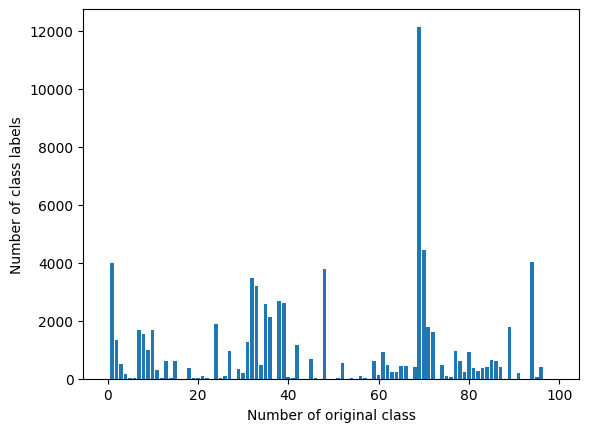

In [17]:
# Calculate the original labels statistic
processor.plot_original_class_statistics()

In [18]:
# Count empty images (i.e. images without bounding boxes)
empty_names, empty_images = processor.analyze_empty_bboxes()

Empty images:  234


In [ ]:
# Separate empty bounding boxes files
processor.setup_empty_dir()

Total bounding boxes (Fine24 + Empty): 7939


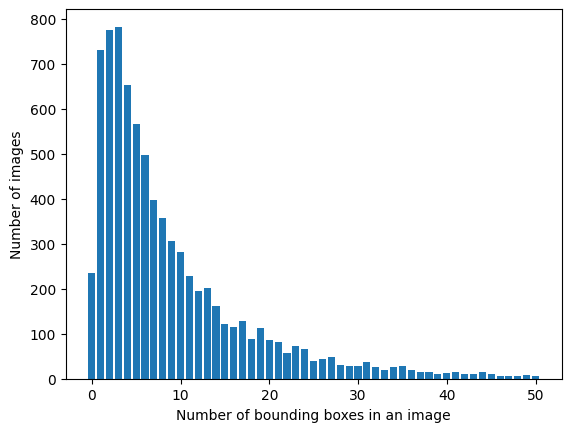

In [20]:
# Calculate bounding boxes by images statistic (including empty)
# Separate excluded images (images with more than 50 bboxes)
excluded_list = processor.analyze_bbox_statistics(max_bboxes=50)

Total excluded images: 122
/media/igor/Data/Projects/CropAndWeedDetection/cropandweed-dataset/data/bboxes/Fine24/ave-0355-0009.csv


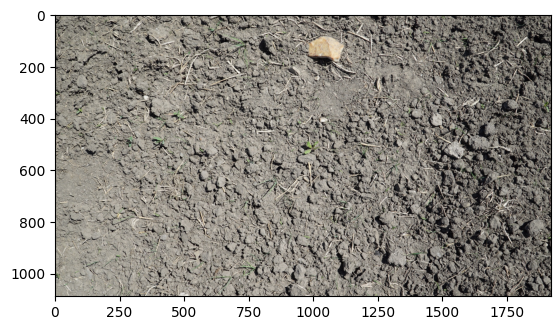

/media/igor/Data/Projects/CropAndWeedDetection/cropandweed-dataset/data/bboxes/Fine24/ave-0057-0008.csv


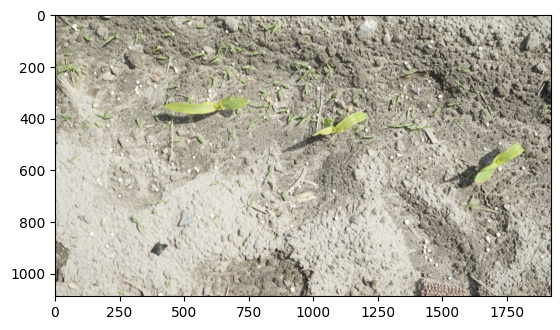

/media/igor/Data/Projects/CropAndWeedDetection/cropandweed-dataset/data/bboxes/Fine24/vwg-0880-0009.csv


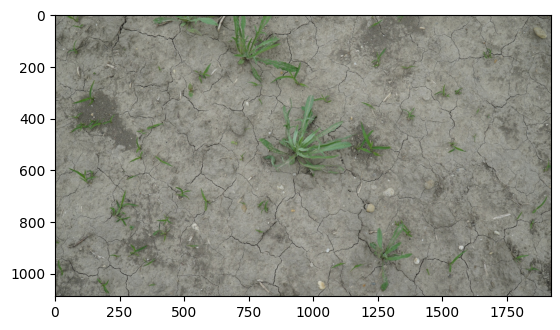

/media/igor/Data/Projects/CropAndWeedDetection/cropandweed-dataset/data/bboxes/Fine24/ave-0148-0001.csv


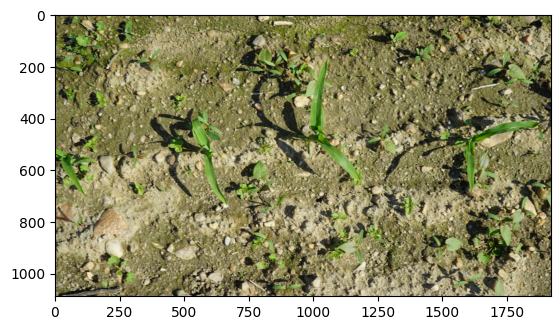

/media/igor/Data/Projects/CropAndWeedDetection/cropandweed-dataset/data/bboxes/Fine24/vwg-0880-0011.csv


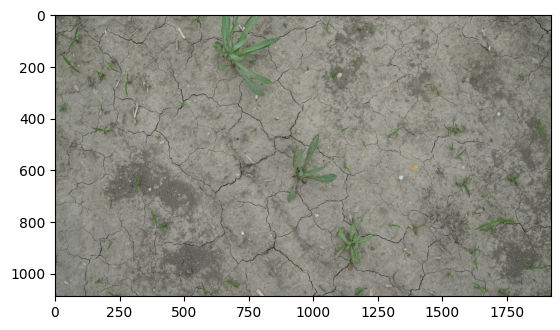

In [21]:
# Show some excluded images
processor.display_excluded_images()

In [22]:
# Get the clean dataset
fine24_bboxes_clean = processor.get_clean_dataset()

Excluded 122 images.
Clean dataset size: 7817


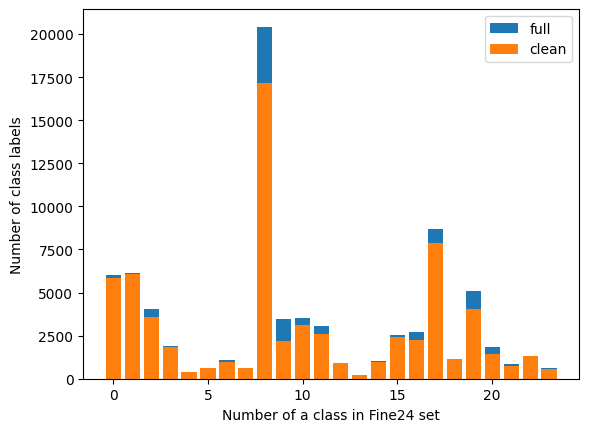

In [23]:
# Calculate the Fine24 labels statistic (both full dataset and clean dataset)
processor.plot_class_statistics()

In [24]:
# Final clean dataset output
print(f"Final clean dataset ready with {len(fine24_bboxes_clean)} images.")

Final clean dataset ready with 7817 images.


## 3. YOLO Data Conversion Class

This section takes the cleaned dataset from the previous steps and converts it into a format ready for YOLO training. 

We define a new class, `YoloDataConverter`, which will use the `processor` instance to access helper methods like `read_image`, `read_bboxes`, etc.

In [25]:
# --- (This class assumes a 'DatasetProcessor' instance is passed to it) ---

class YoloDataConverter:
    """
    Handles the conversion of the cleaned dataset into YOLO format.
    Relies on an existing DatasetProcessor for file I/O utilities.
    """
    
    def __init__(self, processor, clean_bboxes_list):
        """
        Initializes the converter with the processor and clean data.
        
        Args:
            processor (DatasetProcessor): An initialized instance of DatasetProcessor.
            clean_bboxes_list (list): The list of clean bbox file paths.
        """
        self.processor = processor
        self.clean_bboxes_list = clean_bboxes_list
        
        # Inherit necessary paths and info from the processor
        self.DATA_PATH = self.processor.DATA_PATH
        self.IMAGES_PATH = self.processor.IMAGES_PATH
        self.IMAGE_WIDTH = self.processor.IMAGE_WIDTH
        self.IMAGE_HEIGHT = self.processor.IMAGE_HEIGHT
        self.f24_labels = self.processor.f24_labels
        self.FINE24_NUM_CLASSES = self.processor.FINE24_NUM_CLASSES
        self.category_index_list = self.processor.category_index_list
        self.YOLO_DATASET_DIR = Path(".").joinpath('yolo-dataset').resolve()
        
        # Define new paths for this class
        self.CUT_IMAGES_PATH = self.DATA_PATH.joinpath('cut_images')
        
        # Initialize state attributes
        self.s_bboxes = []
        self.yaml_strings = []
        self.dataset_size = len(self.clean_bboxes_list)

    @staticmethod
    def split_bboxes(bboxes, train_ratio=0.8, validation_ratio=0.1):
        """Splits the dataset by train/valid/test ratio (from cell 13)"""
        assert (train_ratio + validation_ratio) < 1
        total_size = len(bboxes)
        train_count = int(total_size * train_ratio)
        validation_count = int(total_size * validation_ratio)
        test_count = total_size - (train_count + validation_count)

        train_bboxes = bboxes[:train_count]
        validation_bboxes = bboxes[train_count:train_count + validation_count]
        test_bboxes = bboxes[train_count + validation_count:]

        return [train_bboxes, validation_bboxes, test_bboxes], [train_ratio, validation_ratio, 1 - (train_ratio + validation_ratio)]

    def prepare_and_split_dataset(self, train_ratio=0.8, validation_ratio=0.1, seed=10):
        """Creates output dir and splits dataset (from cell 14)"""
        print(f"Preparing to split dataset of size: {self.dataset_size}")
        self.CUT_IMAGES_PATH.mkdir(parents=True, exist_ok=True)
        
        # Sort and shuffle the clean dataset list
        self.clean_bboxes_list.sort()
        random.seed(seed)
        random.shuffle(self.clean_bboxes_list)
        
        self.s_bboxes, s_ratios = self.split_bboxes(self.clean_bboxes_list, train_ratio, validation_ratio)
        print(f"Dataset split complete. Ratios: {s_ratios}")
        print(f"Train: {len(self.s_bboxes[0])}, Validation: {len(self.s_bboxes[1])}, Test: {len(self.s_bboxes[2])}")

    def _convert_split_to_yolo(self, bboxes, categories, image_in_path, image_out_path, ann_name,
                                 image_convert=False, image_cut_size=1024, tolerance=8):
        """Core conversion logic (from cell 16), uses processor methods."""
        coco_dataset = {
            "info": {}, "licenses": [], "categories": categories,
            "images": [], "annotations": []
        }
        img_paths = []

        self.YOLO_DATASET_DIR.mkdir(parents=True, exist_ok=True)

        for img_id, bbox_filename in zip(tqdm(range(len(bboxes))), bboxes):
            if image_convert:
                # Use the processor's read_image method
                image = self.processor.read_image(bbox_filename, image_in_path)
                image_left = image[:image_cut_size, :image_cut_size, :]
                image_right = image[:image_cut_size, -image_cut_size:, :]
            else:
                image = np.zeros((self.IMAGE_HEIGHT, self.IMAGE_WIDTH, 3))

            left_img_path = image_out_path.joinpath(bbox_filename.stem + '_l.jpg')
            right_img_path = image_out_path.joinpath(bbox_filename.stem + '_r.jpg')
            left_ann_path = image_out_path.joinpath(bbox_filename.stem + '_l.txt')
            right_ann_path = image_out_path.joinpath(bbox_filename.stem + '_r.txt')

            if image_convert:
                # Use the processor's write_image method
                self.processor.write_image(image_left, left_img_path)
                self.processor.write_image(image_right, right_img_path)

            img_paths.append(left_img_path)
            img_paths.append(right_img_path)

            coco_dataset["images"].append({
                "id": img_id * 2, "width": image_cut_size, "height": image_cut_size,
                "file_name": str(left_img_path)
            })
            coco_dataset["images"].append({
                "id": img_id * 2 + 1, "width": image_cut_size, "height": image_cut_size,
                "file_name": str(right_img_path)
            })

            # Use the processor's read_bboxes method
            boxes, labels, stems = self.processor.read_bboxes(Path(bbox_filename))
            left_ann_dict = {"bboxes": [], "category_ids": [], "stems": []}
            right_ann_dict = {"bboxes": [], "category_ids": [], "stems": []}

            for label_id in range(len(labels)):
                left, top, right, bottom = map(float, boxes[label_id])
                if top >= image_cut_size - tolerance: continue
                if bottom >= image_cut_size: bottom = image_cut_size - 1
                w = right - left
                h = bottom - top
                
                if left < image_cut_size - tolerance:
                    w_l = w
                    if right >= image_cut_size: w_l = image_cut_size - 1 - left
                    left_ann_dict['bboxes'].append([left, top, left + w_l, top + h])
                    left_ann_dict['category_ids'].append(int(labels[label_id]))
                    left_ann_dict['stems'].append(stems[label_id])
                    coco_dataset["annotations"].append({
                        "id": len(coco_dataset["annotations"]) + 1, "image_id": img_id * 2,
                        "category_id": int(labels[label_id]) + 1, "bbox": [left, top, w_l, h],
                        "area": w_l * h, "iscrowd": 0
                    })
                
                if right > image.shape[1] - image_cut_size + tolerance:
                    left_r = left
                    w_r = w
                    if left < image.shape[1] - image_cut_size:
                        left_r = image.shape[1] - image_cut_size
                        w_r = right - left_r
                    bbox_r_coords = [left_r - image.shape[1] + image_cut_size, top,
                                     left_r - image.shape[1] + image_cut_size + w_r, top + h]
                    right_ann_dict['bboxes'].append(bbox_r_coords)
                    right_ann_dict['category_ids'].append(int(labels[label_id]))
                    right_ann_dict['stems'].append(stems[label_id])
                    coco_dataset["annotations"].append({
                        "id": len(coco_dataset["annotations"]) + 1, "image_id": img_id * 2 + 1,
                        "category_id": int(labels[label_id]) + 1, "bbox": [bbox_r_coords[0], top, w_r, h],
                        "area": w_r * h, "iscrowd": 0
                    })

            for (ann_dict, ann_path) in zip([left_ann_dict, right_ann_dict], [left_ann_path, right_ann_path]):
                with open(ann_path, "w") as ann:
                    for (box, label, stem) in zip(ann_dict['bboxes'], ann_dict['category_ids'], ann_dict['stems']):
                        x = .5 * (box[2] + box[0]) / image_cut_size
                        y = .5 * (box[3] + box[1]) / image_cut_size
                        w = (box[2] - box[0]) / image_cut_size
                        h = (box[3] - box[1]) / image_cut_size
                        print(f"{label} {x} {y} {w} {h}", file=ann)

        with open(ann_name, "w") as ann:
            for image_path in img_paths:
                print(f"{image_path}", file=ann)

    def create_yolo_dataset_files(self, image_convert=True, image_cut_size=1024):
        """Runs the conversion for train, val, and test splits (from cell 17)"""
        if not self.s_bboxes:
            print("Error: Dataset not split. Call 'prepare_and_split_dataset' first.")
            return

        self.yaml_strings = []
        for bboxes, prefix in zip(self.s_bboxes, ['train', 'val', 'test']):
            print(f"--- Processing {prefix} split --- ")
            annotations_name = str(self.YOLO_DATASET_DIR.joinpath(prefix + '.txt').resolve())
            self._convert_split_to_yolo(bboxes, self.category_index_list, self.IMAGES_PATH,
                                        self.CUT_IMAGES_PATH, annotations_name, 
                                        image_convert=image_convert, 
                                        image_cut_size=image_cut_size)
            self.yaml_strings.append(prefix + ": " + annotations_name)
        print("\nDataset file creation complete.")
#        print(f"YAML strings generated: {self.yaml_strings}")

    def create_yolo_yaml(self, yaml_file_name="CropAndWeed.yaml"):
        self.yaml_name=self.YOLO_DATASET_DIR.joinpath(yaml_file_name)
        """Saves the .yaml config file (from cell 18)"""
        if not self.yaml_strings:
            print("Error: YAML strings not generated. Call 'create_yolo_dataset_files' first.")
            return

        with open(self.yaml_name, "w") as yaml:
            for string in self.yaml_strings:
                print(f"{string}", file=yaml)
            print(f"nc: {self.FINE24_NUM_CLASSES}", file=yaml)
            print("names: [", file=yaml)
            for label in range(self.FINE24_NUM_CLASSES):
                print(f"'{self.f24_labels[label]}',", file=yaml)
            print("]", file=yaml)
        print(f"Successfully saved config to {yaml_file_name}")

    def display_yolo_samples(self, glob_pattern="*0040_l.txt"):
        """Shows some annotated cut images (from cell 19)"""
        print(f"\n--- Displaying samples matching '{glob_pattern}' --- ")
        some_bboxes = list(self.CUT_IMAGES_PATH.glob(glob_pattern))
        some_bboxes.sort()
        
        if not some_bboxes:
            print(f"No images found for pattern: {glob_pattern}")
            return

        for bbox_file in some_bboxes:
            print(f"Displaying: {bbox_file.name}")
            # Use processor methods to read image and YOLO bboxes
            image = self.processor.read_image(Path(bbox_file), self.CUT_IMAGES_PATH)
            bboxes, labels = self.processor.read_yolo_bboxes(Path(bbox_file), image.shape)

            if len(bboxes):
                detections = sv.Detections(xyxy=bboxes, class_id=labels, data={"class_name": [self.f24_labels[i] for i in labels]})
                bounding_box_annotator = sv.BoxAnnotator()
                label_annotator = sv.LabelAnnotator()
                image = bounding_box_annotator.annotate(scene=image, detections=detections)
                image = label_annotator.annotate(scene=image, detections=detections)
            
            plt.figure(dpi=200)
            plt.tick_params(left=False, labelleft=False, labelbottom=False, bottom=False)
            plt.imshow(image)
            plt.show()

## 4. Converting and Saving the YOLO Dataset

Now we will call the methods on our new class to perform the conversion. 

In [26]:
print("--- Instantiating YoloDataConverter ---")
# We pass the processor and the clean data list to the new class
converter = YoloDataConverter(processor, fine24_bboxes_clean)
print("Converter instantiated.")

--- Instantiating YoloDataConverter ---
Converter instantiated.


In [27]:
# Split the dataset into train, validation, and test sets
# This also creates the 'cut_images' directory
converter.prepare_and_split_dataset(seed=10)

Preparing to split dataset of size: 7817
Dataset split complete. Ratios: [0.8, 0.1, 0.09999999999999998]
Train: 6253, Validation: 781, Test: 783


In [28]:
# Convert annotations to YOLO format and cut/save images
# This will create train.txt, val.txt, test.txt
# It also saves the cut images to the 'cut_images' directory
# We set image_convert=True so the images are saved for the next step
converter.create_yolo_dataset_files(image_convert=True)

--- Processing train split --- 


100%|███████████████████████████████████████| 6253/6253 [03:19<00:00, 31.31it/s]


--- Processing val split --- 


100%|█████████████████████████████████████████| 781/781 [00:24<00:00, 31.81it/s]


--- Processing test split --- 


100%|█████████████████████████████████████████| 783/783 [00:24<00:00, 31.85it/s]


Dataset file creation complete.


In [29]:
# Save the final .yaml file for YOLO training
converter.create_yolo_yaml(yaml_file_name="CropAndWeed.yaml")

Successfully saved config to CropAndWeed.yaml


## 5. Displaying Sample YOLO-Formatted Images

Display a few of the newly created and annotated 1024x1024 images to verify the output.

In [ ]:
# Show some annotated cut images from the newly created dataset
# This method uses the processor's read_image and read_yolo_bboxes methods
converter.display_yolo_samples(glob_pattern="*0040_l.txt")

In [ ]:
# Show the right-hand side images as well
converter.display_yolo_samples(glob_pattern="*0040_r.txt")

## 6. Train the YOLO model

Now, we train yolo8 medium model with the converted dataset.

In [1]:
# Check if CUDA is available
import torch
if torch.cuda.is_available():
    print("CUDA is available.")
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available.")
    print("Consider installing torch with CUDA support for faster training.")

CUDA is available.
CUDA version: 12.4
GPU: NVIDIA GeForce RTX 3060 Ti


In [ ]:
from ultralytics import YOLO

In [3]:
# Load the model
model_v8 = YOLO("yolov8m")
# Check the model info
model_v8.info()

YOLOv8m summary: 169 layers, 25,902,640 parameters, 0 gradients, 79.3 GFLOPs


(169, 25902640, 0, 79.3204224)

In [ ]:
# Start training
# We use default yolo augmentation
# Number of epochs (100) allow to reach good values for precision, recall, mAP50 and mAP50-95 on the validation split
# Batch number (4) is ok for 8Gb videocard, could be increased to 8 and higher if the videocard has 12Gb and more memory
model_v8.train(data=converter.yaml_name, epochs=100, batch=4, imgsz=1024)

In [ ]:
# Save the model to ONNX format
model = YOLO("runs/detect/train20/weights/best.pt")
model.export(format="onnx", dynamic=True, simplify=True, opset=12)

## 7. VideoAnnotator Class Definition

This class encapsulates all the logic for processing the video. It is initialized with the necessary paths and the trained YOLO model.

In [36]:
import cv2

In [37]:
class VideoAnnotator:
    """Class to process, track, and annotate a video with a YOLOv8 model."""

    def __init__(self, 
                 input_path: str, 
                 output_path: str, 
                 model: YOLO, 
                 target_size: tuple = (1024, 1024),
                 conf_threshold: float = 0.2, #0.25,
                 iou_threshold: float = 0.45): # 0.45):
        """
        Initializes the VideoAnnotator.

        Args:
            input_path (str): Path to the input MP4 video file.
            output_path (str): Path to save the output annotated video.
            model (YOLO): The trained YOLOv8 model instance.
            target_size (tuple): The target (width, height) to resize frames to.
            conf_threshold (float): NMS confidence threshold for model.predict().
            iou_threshold (float): NMS IoU threshold for model.predict().
        """
        self.input_path = input_path
        self.output_path = output_path
        self.model = model
        self.target_size = target_size
        self.conf_threshold = conf_threshold
        self.iou_threshold = iou_threshold
        self.class_names = model.model.names
        
        # --- Internal state for tracking and smoothing ---
        self.tracker = None
        
        # Dictionary to store probability vectors { track_id: np.array([p0, p1, p2...]) }
        self.track_probs = {} 
        
        # Class Smoothing Factor (Alpha)
        # 0.1 = Very stable (slow to change)
        # 0.5 = Responsive (changes quickly)
        self.alpha = 0.1
        
        # Initialize supervision annotator
        
        self.bounding_box_annotator = sv.BoxAnnotator(
            thickness=2
        )
        
        # --- MODIFIED: Create two label annotators for different positions ---
        self.label_annotator_top = sv.LabelAnnotator(
            text_thickness=1,
            text_scale=0.5,
            text_position=sv.Position.TOP_LEFT
        )
        self.label_annotator_bottom = sv.LabelAnnotator(
            text_thickness=1,
            text_scale=0.5,
            text_position=sv.Position.BOTTOM_LEFT
        )
        
    def update_tracked_classes(self, detections):
        """
        Updates the class probability history for each track and 
        overwrites the current class_id with the most probable one based on history.
        """
        num_classes = len(self.class_names)

        # We need to modify the class_ids in the detections object
        # We iterate by index to allow in-place modification
        for i, (tracker_id, class_id, conf) in enumerate(zip(detections.tracker_id, detections.class_id, detections.confidence)):
            
            track_id = int(tracker_id)
            current_class = int(class_id)
            
            # 1. Create the "Measurement" Vector for this frame
            # (0.0 everywhere, except 'conf' at the detected class index)
            measurement = np.zeros(num_classes)
            measurement[current_class] = conf
            
            # 2. Retrieve previous state (or initialize if new)
            if track_id in self.track_probs:
                previous_probs = self.track_probs[track_id]
            else:
                # If new, initialize strictly with current frame
                previous_probs = measurement
            
            # 3. Apply Exponential Filter: P_new = P_old + alpha * (Measurement - P_old)
            # This boosts the detected class and decays the others
            new_probs = previous_probs + self.alpha * (measurement - previous_probs)
            
            # 4. Save state
            self.track_probs[track_id] = new_probs
            
            # 5. DETERMINE WINNER: Find the index with the highest smoothed probability
            best_class_id = np.argmax(new_probs)
            
            # 6. Overwrite the detection's class_id with the stable one
            detections.class_id[i] = best_class_id
            
            detections.confidence[i] = new_probs[best_class_id]
            
        return detections
        
    def process_video(self):
        """
        Reads the input video, processes each frame with the YOLO model,
        applies tracking and probability smoothing, draws annotations, 
        and saves the result to the output video.
        """
        
        # Open the input video
        cap = cv2.VideoCapture(self.input_path)
        if not cap.isOpened():
            print(f"Error: Could not open video file {self.input_path}")
            return

        # Get video properties
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Initialize the tracker
        self.tracker = sv.ByteTrack(track_activation_threshold=0.2, minimum_matching_threshold=0.8,
                                    lost_track_buffer=fps, frame_rate=fps)
        
        # Define the codec and create VideoWriter object
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(self.output_path, fourcc, fps, self.target_size)

        # SETTINGS FOR VELOCITY FILTER
        # How much can the speed deviate from the average? (in pixels per frame)
        VELOCITY_TOLERANCE = 1.0 

        print(f"Processing {frame_count} frames at {fps} fps with Velocity Filtering and Temporal Class Smoothing...")

        for _ in tqdm(range(frame_count)):
            ret, frame = cap.read()
            if not ret: break

            frame_resized = cv2.resize(frame, self.target_size)

            # Inference
            results = self.model.track(
                frame_resized, 
                imgsz=self.target_size[0], 
                conf=self.conf_threshold, 
                iou=self.iou_threshold,
                agnostic_nms=True,
                persist=True,
                verbose=False
            )[0]
            
            # Real Detections
            detections = sv.Detections.from_ultralytics(results)
            
            # Update Tracker
            detections = self.tracker.update_with_detections(detections)
            
            # --- UPDATE CLASS PROBABILITIES ---
            # This stabilizes the labels by looking at history
            if detections.tracker_id is not None:
                detections = self.update_tracked_classes(detections)

            # --- Clear Data for Merging ---
            detections.data = {}      
            
            # ---: VELOCITY CONSISTENCY CHECK ---
            
            # Calculate Global Mean Velocity from ACTIVE tracks
            # The STrack.mean attribute is usually [x, y, a, h, vx, vy, va, vh]
            # We look at indices 4 (vx) and 5 (vy)
            active_velocities = []
            
            # Access internal tracked tracks
            internal_tracker = getattr(self.tracker, 'tracker', self.tracker)
            tracked_tracks = getattr(internal_tracker, 'tracked_tracks', [])
            
            active_velocities = []
            for t in tracked_tracks:
                if hasattr(t, 'mean'):
                    active_velocities.append([t.mean[4], t.mean[5]]) # vx, vy
            
            if len(active_velocities) > 0:
                mean_velocity = np.mean(active_velocities, axis=0)
            else:
                mean_velocity = np.array([0.0, 0.0])

            # Filter LOST tracks based on this Mean Velocity
            valid_ghosts_xyxy = []
            valid_ghosts_ids = []
            valid_ghosts_class = []
            valid_ghosts_conf = []

            lost_tracks = getattr(internal_tracker, 'lost_tracks', [])

            for t in lost_tracks:
                # -- EXTRACT ID
                t_id = getattr(t, 'external_track_id', getattr(t, 'internal_track_id', -1))
                if t_id == -1: continue # Skip if totally broken

                # --- Retrieve Class from PROBABILITY vector ---
                if t_id in self.track_probs:
                    # Use the argmax of the stored probability vector
                    t_probs = self.track_probs[t_id]
                    t_cls = np.argmax(t_probs)
                    t_prob = t_probs[t_cls]
                else:
                    # Fallback if we somehow missed it (rare)
                    t_cls = 0
                    t_prob = 0

                # -- EXTRACT GEOMETRY --
                t_tlbr = getattr(t, 'tlbr', getattr(t, 'xyxy', None))
                if t_tlbr is None: continue
                
                # -- VELOCITY CHECK --
                if hasattr(t, 'mean') and len(active_velocities) > 0:
                    track_v = np.array([t.mean[4], t.mean[5]])
                    if np.linalg.norm(track_v - mean_velocity) > VELOCITY_TOLERANCE:
                        continue # Skip if speed is weird

                # Add to valid list
                valid_ghosts_xyxy.append(t_tlbr)
                valid_ghosts_ids.append(t_id)
                valid_ghosts_class.append(t_cls)
                valid_ghosts_conf.append(t_prob)

            # Merge "Good Ghosts" into Real Detections
            if len(valid_ghosts_xyxy) > 0:
                ghost_detections = sv.Detections(
                    xyxy=np.array(valid_ghosts_xyxy),
                    class_id=np.array(valid_ghosts_class),
                    tracker_id=np.array(valid_ghosts_ids),
                    confidence=np.array(valid_ghosts_conf)
                )
                
                # Clear metadata to allow merging
                detections.data = {} 
                ghost_detections.data = {} 
                
                detections = sv.Detections.merge([detections, ghost_detections])
   

            # --- Standard Annotation (includes valid ghosts) ---
            labels = [
                f"#{tracker_id} {self.class_names[class_id]} {confidence:0.1f}"
                for _, _, confidence, class_id, tracker_id, _
                in detections
            ]
            
            annotated_frame = self.bounding_box_annotator.annotate(
                scene=frame_resized.copy(), 
                detections=detections
            )
            
            # Draw Labels conditionally ---
            if len(detections) > 0:
                # Create mask for boxes at the top of the frame
                y_min_values = detections.xyxy[:, 1]
                top_mask = y_min_values < 5  # 5-pixel threshold for "at the top"
                other_mask = ~top_mask

                # Split detections and labels based on the mask
                detections_top = detections[top_mask]
                detections_other = detections[other_mask]
                labels_top = [label for label, is_top in zip(labels, top_mask) if is_top]
                labels_other = [label for label, is_top in zip(labels, top_mask) if not is_top]

                # Annotate "other" detections at the TOP of the box
                annotated_frame = self.label_annotator_top.annotate(
                    scene=annotated_frame, 
                    detections=detections_other, 
                    labels=labels_other
                )
                # Annotate "top" detections at the BOTTOM of the box
                annotated_frame = self.label_annotator_bottom.annotate(
                    scene=annotated_frame, 
                    detections=detections_top, 
                    labels=labels_top
                )

            out.write(annotated_frame)

        # Release Resources ---
        cap.release()
        out.release()
        print(f"\nProcessing complete. Video saved to: {self.output_path}")

## 8. Video processing

Now we annotate the video file

In [ ]:
# --- 1. Define Paths and parameters ---
MODEL_PATH = Path('./runs/detect/train2/weights/best.pt')
INPUT_VIDEO_PATH = Path('./video/Moving.mp4')
OUTPUT_VIDEO_PATH = Path('./video/Moving_annotated.mp4')
TARGET_FRAME_SIZE = (1024, 1024)

# --- 2. Load Model ---
if not Path(MODEL_PATH).exists():
    print(f"Error: Model file not found at {MODEL_PATH}")
    print("Please update MODEL_PATH to point to your 'best.pt' file.")
else:
    print(f"Loading model from {MODEL_PATH}...")
    model = YOLO(MODEL_PATH)
    print(f"Model loaded. Class names: {model.model.names}")
    # --- 3. Instantiate and Run Annotator ---
    if not Path.exists(INPUT_VIDEO_PATH):
        print(f"Error: Input video not found at {INPUT_VIDEO_PATH}")
        print("Please update INPUT_VIDEO_PATH.")
    else:
        annotator = VideoAnnotator(
            input_path=INPUT_VIDEO_PATH,
            output_path=OUTPUT_VIDEO_PATH,
            model=model,
            target_size=TARGET_FRAME_SIZE,
            # We can now pass conf and iou thresholds if we want to change NMS behavior
            # We'll use the defaults (conf=0.25, iou=0.45) for this example
            # e.g., to be stricter:
    #        conf_threshold=0.3, iou_threshold=0.4
        )
            
        # --- 4. Process the Video ---
        annotator.process_video()